Load Data

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# --- Additional Imports for Advanced EDA ---
import missingno as msno
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('data.csv', low_memory=False)

# 2. Define Target Variable
df = df[df['loan_status'] != 'Current'].copy()
bad_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 'Does not meet the credit policy. Status:Charged Off']
df['default_flag'] = df['loan_status'].isin(bad_statuses).astype(int)

# 3. Remove Data Leakage (Post-Origination Metrics)
leakage_features = [
    'loan_status', # Dropping the original target variable text column
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 
    'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status', 
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 
    'hardship_loan_status', 'orig_projected_additional_accrued_interest', 
    'debt_settlement_flag', 'settlement_status', 'settlement_amount'
]

# Drop the leakage features (errors='ignore' prevents crashes if some columns aren't in your sample)
df = df.drop(columns=leakage_features, errors='ignore')

print(f"Initial shape after removing leakage features: {df.shape}")

Initial shape after removing leakage features: (606366, 113)


Define Target Variable

In [43]:
# 1. Clean Percentages in-place
for col in ['int_rate', 'revol_util']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.rstrip('%').astype(float) / 100.0

# 2. Clean Employment Length in-place
if 'emp_length' in df.columns:
    # Extract the number, replace the original column
    df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').astype(float)

print("Data formatting complete. No new columns were created.")
print(f"Shape after formatting: {df.shape}")

Data formatting complete. No new columns were created.
Shape after formatting: (606366, 113)


Eliminate Data Leakage

In [44]:
"""# 1. Separate Features and Target
X = df.drop('default_flag', axis=1)
y = df['default_flag']

# 2. Auto-detect Numerical vs Categorical columns based on the current X
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 4. Build Preprocessor (Using ORDINAL ENCODER)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    # OrdinalEncoder converts text to integers (0, 1, 2...) instead of splitting columns
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# 5. Define and Train XGBoost
spw = (len(y_train) - sum(y_train)) / sum(y_train) if sum(y_train) > 0 else 1

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=spw, 
    n_estimators=200, 
    max_depth=6, 
    learning_rate=0.1,
    random_state=42, 
    n_jobs=-1, 
    eval_metric='logloss'
)

# Create Full Pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb_model)])

print(f"Training XGBoost Model on exactly {X_train.shape[1]} features...")
pipeline.fit(X_train, y_train)
print("✅ Training Complete.")
print(f"Shape after formatting: {df.shape}")"""

'# 1. Separate Features and Target\nX = df.drop(\'default_flag\', axis=1)\ny = df[\'default_flag\']\n\n# 2. Auto-detect Numerical vs Categorical columns based on the current X\nnum_cols = X.select_dtypes(include=[np.number]).columns.tolist()\ncat_cols = X.select_dtypes(include=[\'object\', \'category\']).columns.tolist()\n\n# 3. Train/Test Split\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)\n\n# 4. Build Preprocessor (Using ORDINAL ENCODER)\nnumeric_transformer = Pipeline(steps=[\n    (\'imputer\', SimpleImputer(strategy=\'median\')),\n    (\'scaler\', StandardScaler())\n])\n\ncategorical_transformer = Pipeline(steps=[\n    (\'imputer\', SimpleImputer(strategy=\'constant\', fill_value=\'missing\')),\n    # OrdinalEncoder converts text to integers (0, 1, 2...) instead of splitting columns\n    (\'ordinal\', OrdinalEncoder(handle_unknown=\'use_encoded_value\', unknown_value=-1))\n])\n\npreprocessor = ColumnTransformer(transformers

Data Formating and Cleaning

XGBoost Performance (Strict Feature Count)
ROC-AUC Score: 0.7273

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.91      0.83        11
           1       0.50      0.25      0.33         4

    accuracy                           0.73        15
   macro avg       0.63      0.58      0.58        15
weighted avg       0.70      0.73      0.70        15


Verification: The model trained on exactly 15 columns.


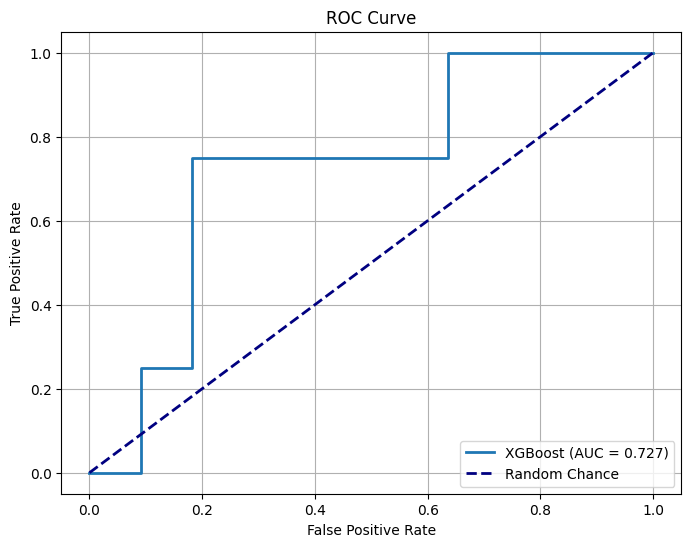

Shape after formatting: (606366, 113)


In [45]:
# 1. Clean Percentage Strings (e.g., "18.25%" -> 0.1825)
pct_cols = ['int_rate', 'revol_util']# Predict
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Metrics
auc = roc_auc_score(y_test, y_proba)

print(f"{'='*40}\nXGBoost Performance (Strict Feature Count)\n{'='*40}")
print(f"ROC-AUC Score: {auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Check the number of features the model actually saw
encoded_feature_count = pipeline.named_steps['preprocessor'].transform(X_train).shape[1]
print(f"\nVerification: The model trained on exactly {encoded_feature_count} columns.")

# Optional: Plot the ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, lw=2, label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
print(f"Shape after formatting: {df.shape}")

In [70]:
# Save the first 500 rows of the cleaned dataset to a CSV file
sample_df = df.head(500).copy()
sample_df.to_csv('processed_dataset_sample_500.csv', index=False)

# Optional: display a direct download link in Jupyter
from IPython.display import FileLink
display(FileLink('processed_dataset_sample_500.csv'))

/Users/WinstonGarth/Downloads/fyp/processed_dataset_sample_500.csv

In [46]:
# --- Cell: Inspect Final Cleaned Data ---

print(f"Final Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nFirst 5 rows of the final dataset (Ready for Modeling):")

# Display the dataframe (in Jupyter, 'display' formats it as a nice HTML table)
display(df.head(20))

# Optional: Print out the exact list of columns that survived the cut
print("\nFinal Features being fed into the model:")
print(df.columns.tolist())
print(f"Shape after formatting: {df.shape}")

Final Dataset Shape: 606366 rows and 113 columns

First 5 rows of the final dataset (Ready for Modeling):


,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,hardship_payoff_balance_amount,hardship_last_payment_amount,default_flag
0,0,1077501,5000.0,5000.0,4975.0,36 months,0.1065,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1,1077430,2500.0,2500.0,2500.0,60 months,0.1527,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2,1077175,2400.0,2400.0,2400.0,36 months,0.1596,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,3,1076863,10000.0,10000.0,10000.0,36 months,0.1349,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,4,1075358,3000.0,3000.0,3000.0,60 months,0.1269,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,5,1075269,5000.0,5000.0,5000.0,36 months,0.0790,156.46,A,A4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
6,6,1069639,7000.0,7000.0,7000.0,60 months,0.1596,170.08,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7,7,1072053,3000.0,3000.0,3000.0,36 months,0.1864,109.43,E,E1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
8,8,1071795,5600.0,5600.0,5600.0,60 months,0.2128,152.39,F,F2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
9,9,1071570,5375.0,5375.0,5350.0,60 months,0.1269,121.45,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1



Final Features being fed into the model:
['Unnamed: 0', 'id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'pymnt_plan', 'url', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_

Bivariate Analysis

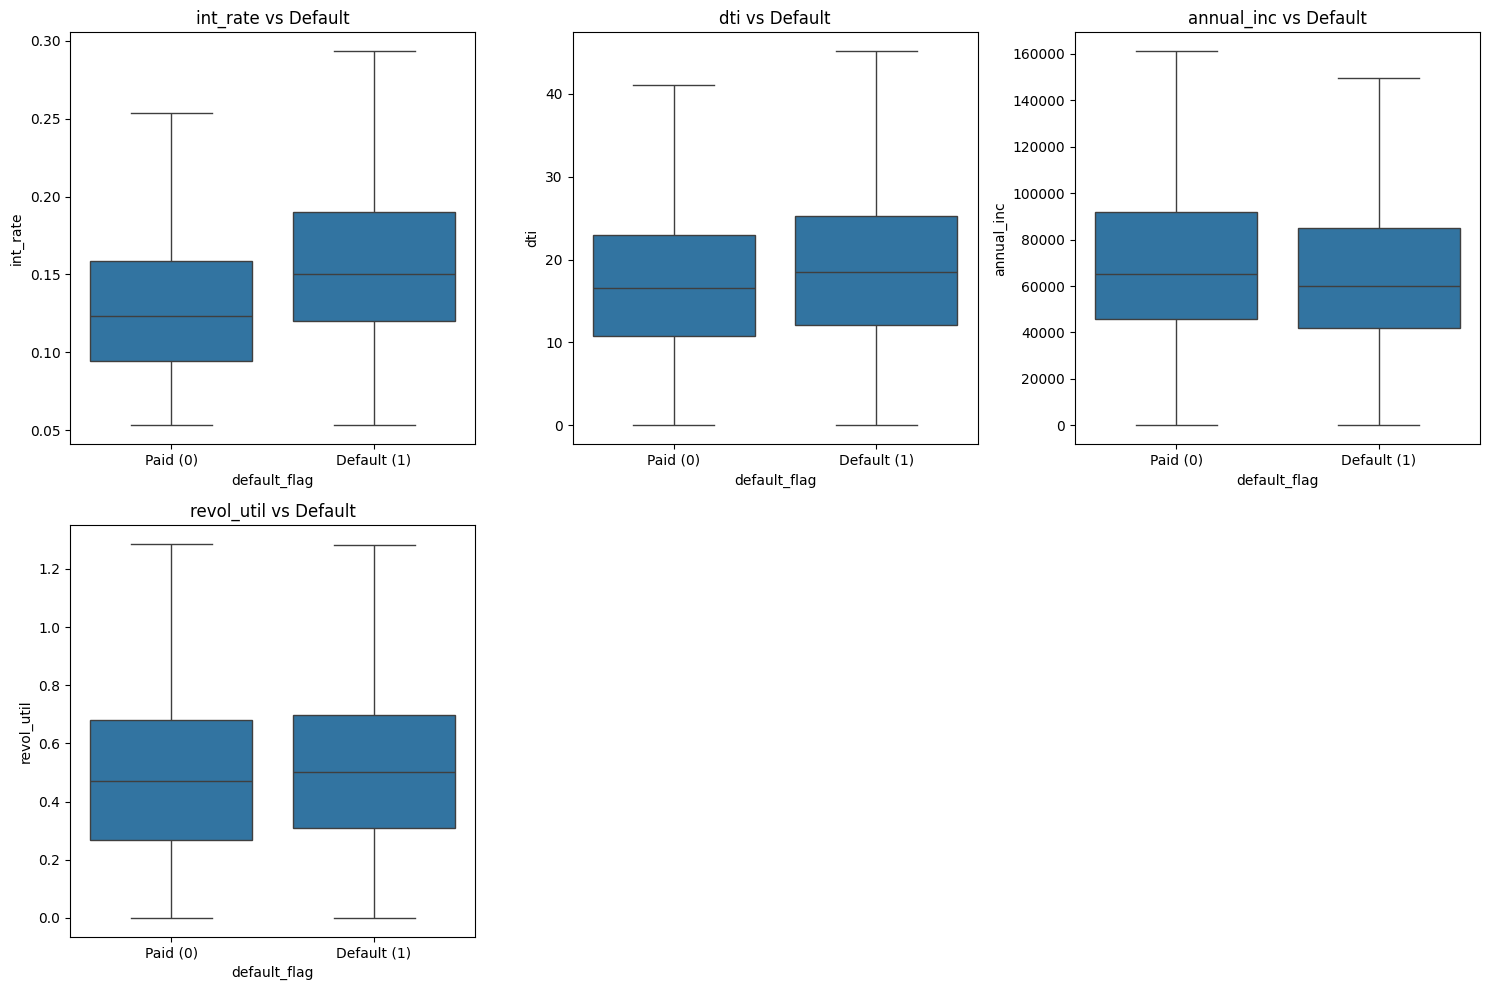

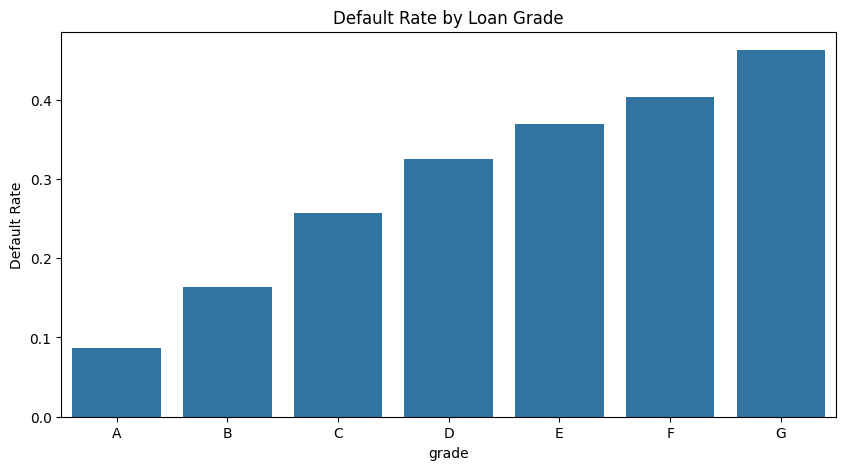

Shape after formatting: (606366, 113)


In [47]:
# Bivariate Analysis: Numerical Features vs Default Flag
num_features = ['int_rate', 'dti', 'annual_inc', 'revol_util', 'cr_hist_months']
valid_features = [f for f in num_features if f in df.columns]

plt.figure(figsize=(15, 10))
for i, feature in enumerate(valid_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='default_flag', y=feature, data=df, showfliers=False)
    plt.title(f'{feature} vs Default')
    plt.xticks([0, 1], ['Paid (0)', 'Default (1)'])
plt.tight_layout()
plt.show()

# Bivariate Analysis: Categorical Feature (Grade)
if 'grade' in df.columns:
    plt.figure(figsize=(10, 5))
    grade_default_rate = df.groupby('grade')['default_flag'].mean().reset_index()
    sns.barplot(x='grade', y='default_flag', data=grade_default_rate, order=sorted(df['grade'].dropna().unique()))
    plt.title('Default Rate by Loan Grade')
    plt.ylabel('Default Rate')
    plt.show()

print(f"Shape after formatting: {df.shape}")

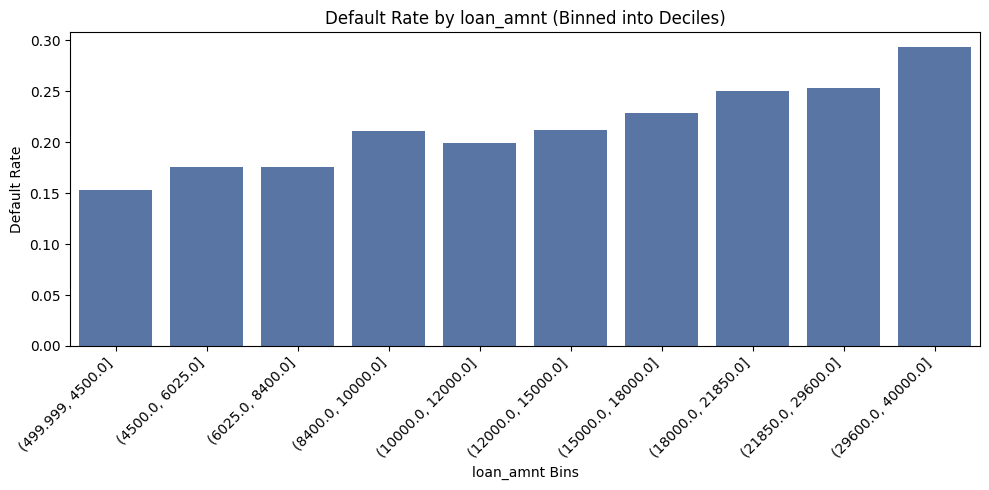

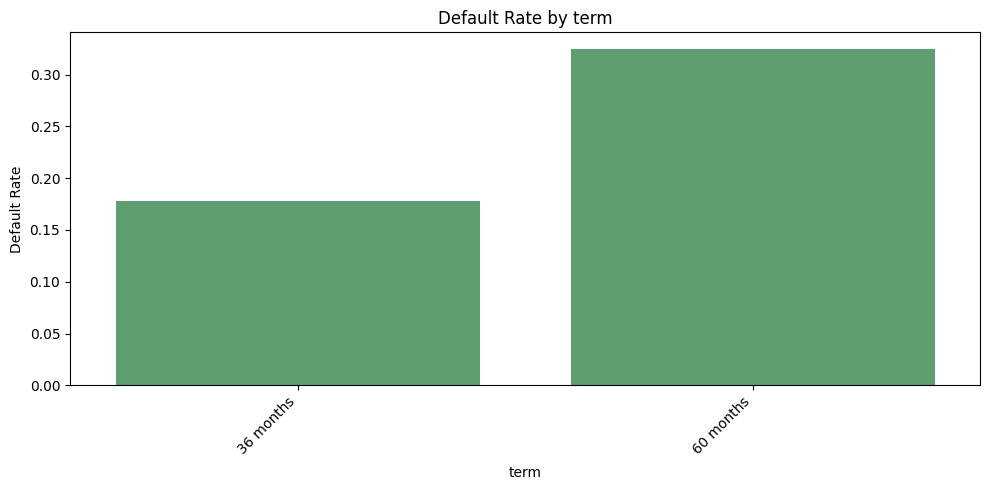

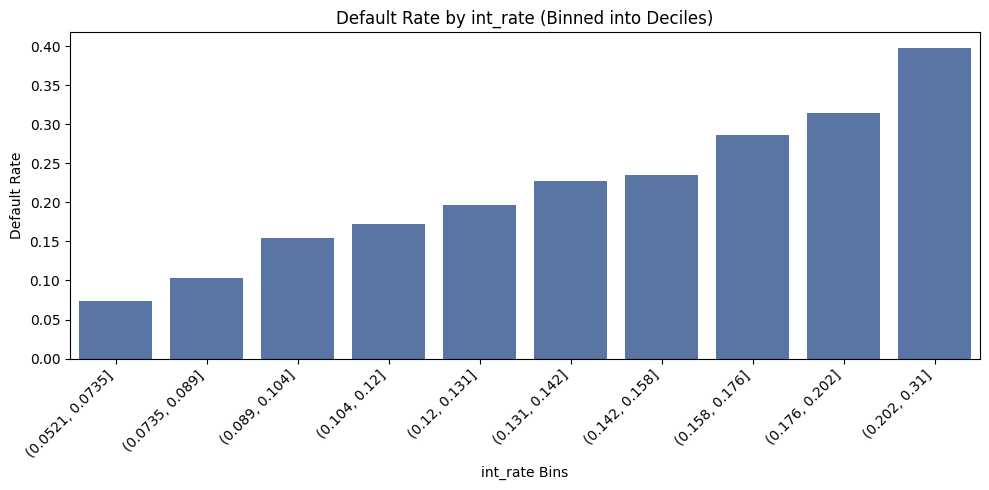

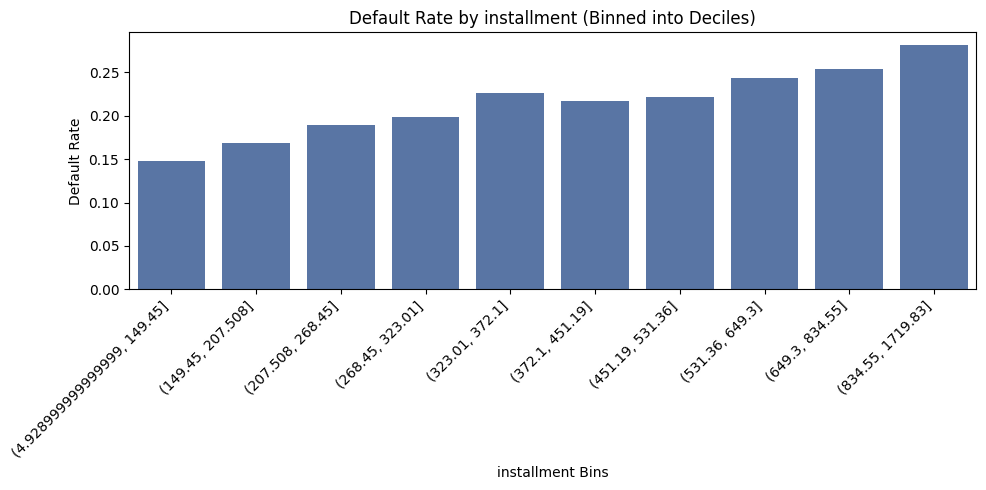

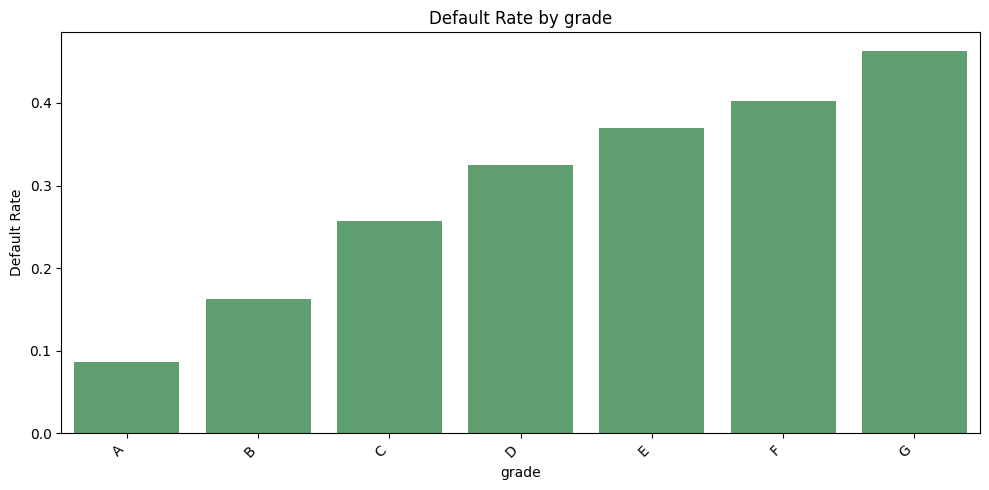

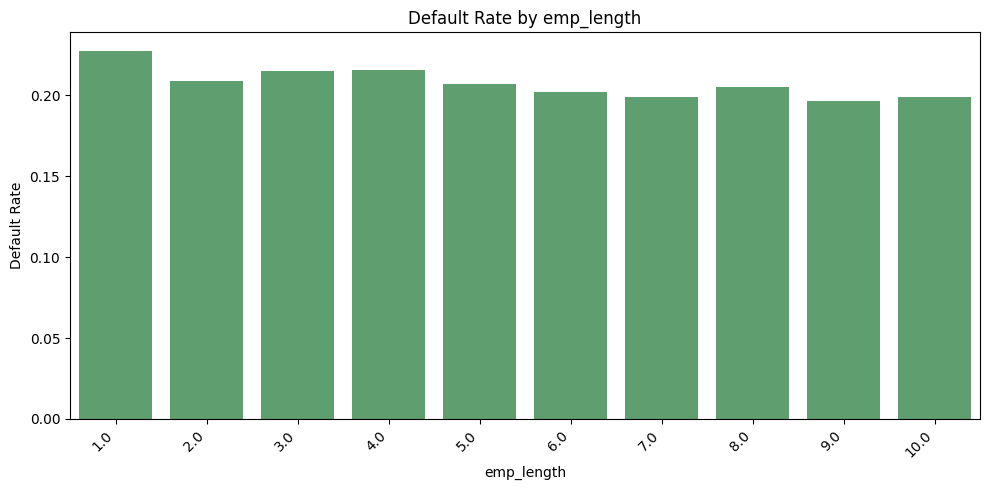

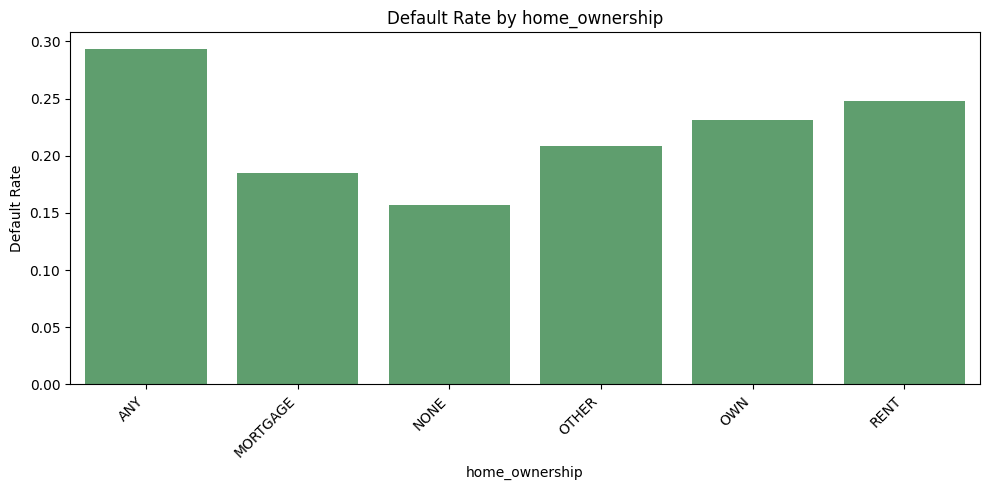

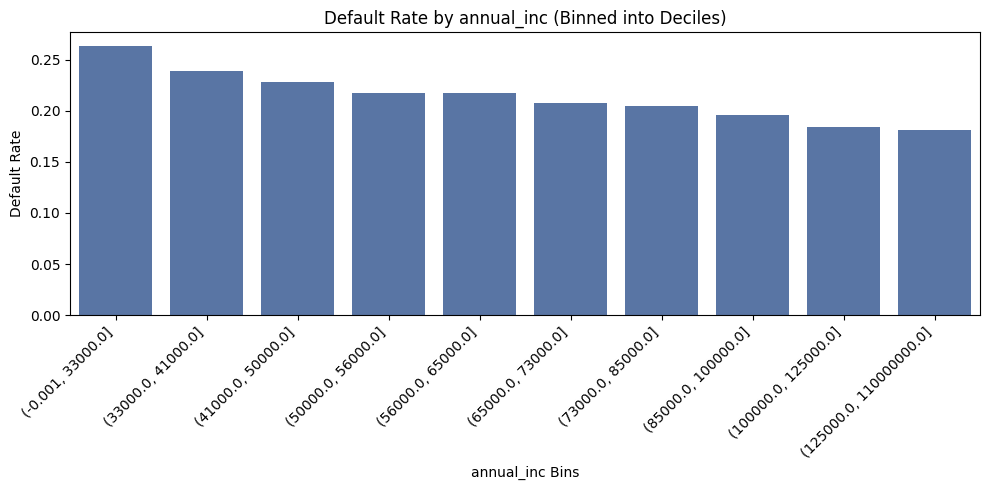

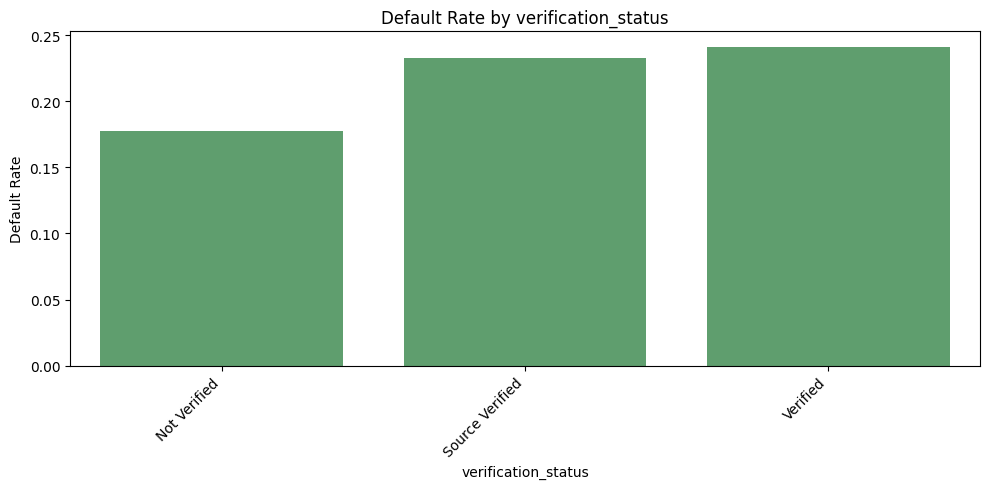

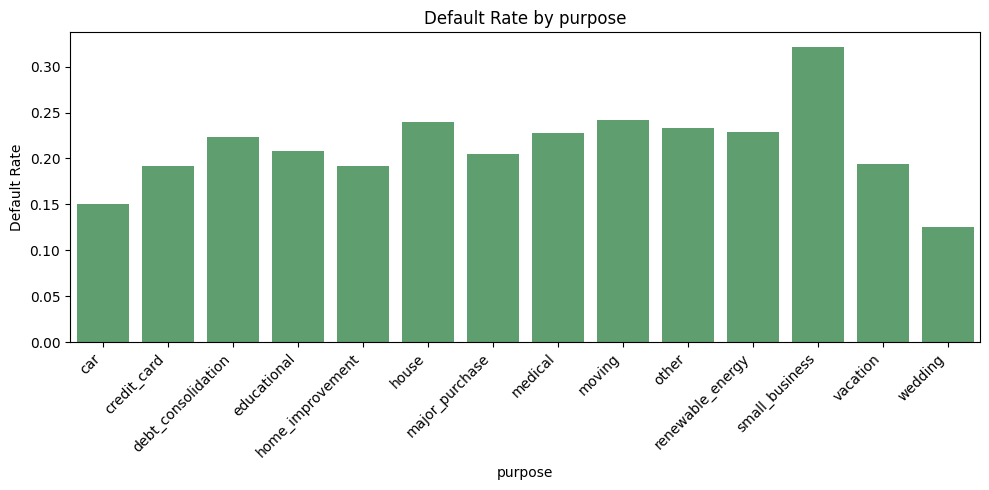

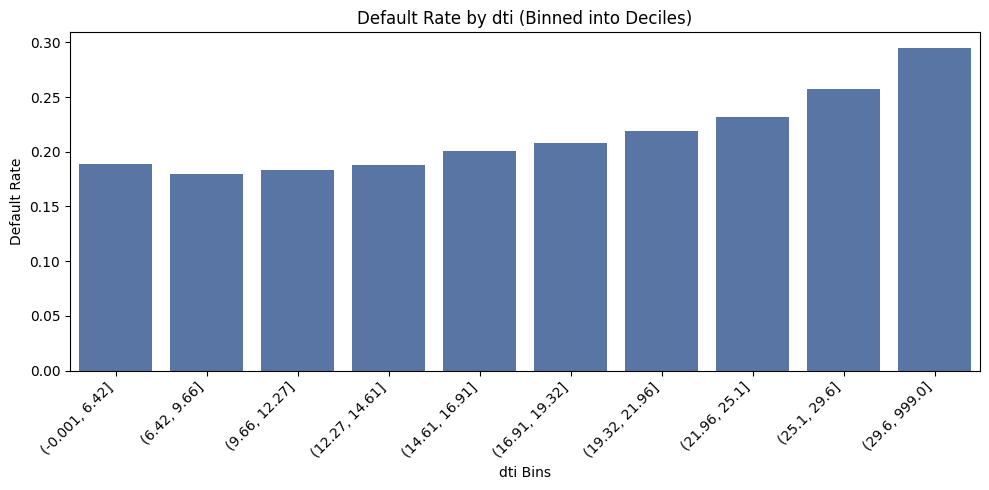

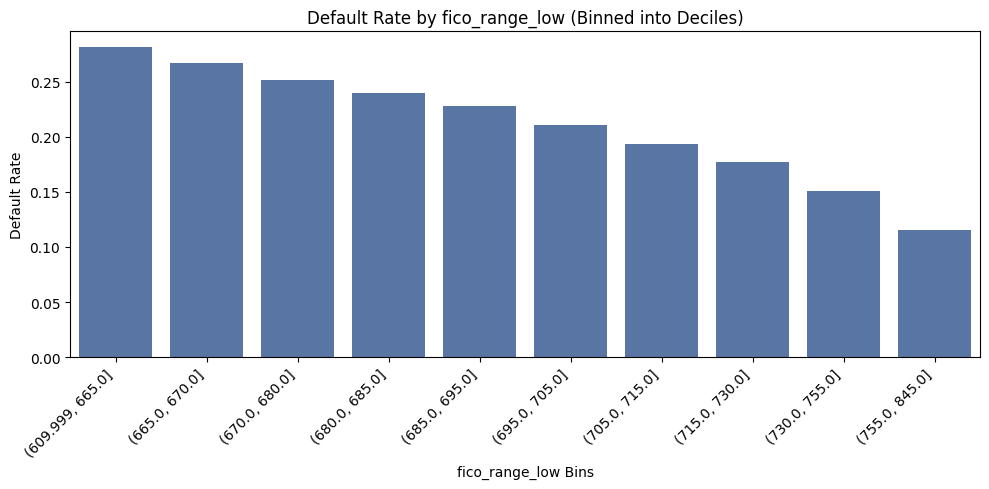

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import is_numeric_dtype

# 1. The list of features from your screenshot
features_to_analyze = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 
    'purpose', 'dti', 'fico_range_low'
]

# Ensure we only try to plot features that actually exist in your dataframe
valid_features = [f for f in features_to_analyze if f in df.columns]

for feature in valid_features:
    plt.figure(figsize=(10, 5))
    
    # Check if numerical AND has many unique values (meaning it's continuous, not categorical/binary)
    if is_numeric_dtype(df[feature]) and df[feature].nunique() > 15:
        
        # --- NUMERICAL PROCESSING (Binning) ---
        # Create a temporary dataframe dropping NaNs for clean binning
        df_plot = df[[feature, 'default_flag']].dropna().copy()
        
        binned_col_name = f'{feature}_binned'
        df_plot[binned_col_name] = pd.qcut(df_plot[feature], q=10, duplicates='drop')
        
        # Calculate Default Rate
        rate_df = df_plot.groupby(binned_col_name)['default_flag'].mean().reset_index()
        
        # Plot Binned Data
        sns.barplot(x=binned_col_name, y='default_flag', data=rate_df, color='#4C72B0')
        plt.title(f'Default Rate by {feature} (Binned into Deciles)')
        plt.xlabel(f'{feature} Bins')
        
    else:
        
        # --- CATEGORICAL PROCESSING ---
        df_plot = df[[feature, 'default_flag']].dropna().copy()
        
        # Calculate Default Rate
        rate_df = df_plot.groupby(feature)['default_flag'].mean().reset_index()
        
        # Sort categorical values so they appear in a logical order on the axis
        rate_df = rate_df.sort_values(by=feature)
        
        # Plot Categorical Data
        sns.barplot(x=feature, y='default_flag', data=rate_df, color='#55A868')
        plt.title(f'Default Rate by {feature}')
        plt.xlabel(feature)

    # Universal formatting for all plots
    plt.ylabel('Default Rate')
    plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
    plt.tight_layout()
    plt.show()

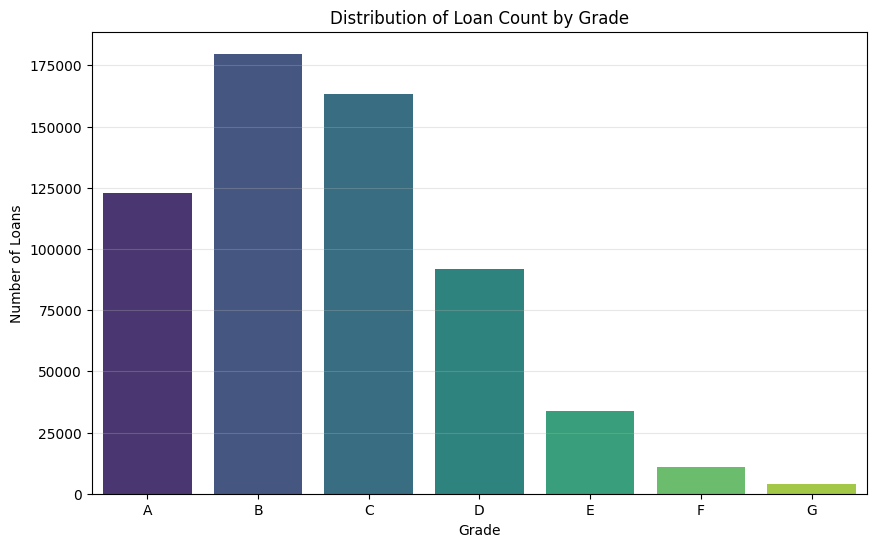

Loan Count Distribution by Grade:
grade
A    122870
B    179746
C    163236
D     91850
E     33899
F     10986
G      3778
Name: count, dtype: int64

Total Loans: 606365


In [66]:
# Distribution of loan count by grade
grade_counts = df['grade'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='viridis')
plt.title('Distribution of Loan Count by Grade')
plt.xlabel('Grade')
plt.ylabel('Number of Loans')
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Loan Count Distribution by Grade:")
print(grade_counts)
print(f"\nTotal Loans: {grade_counts.sum()}")

Correlation and Multicollinearity

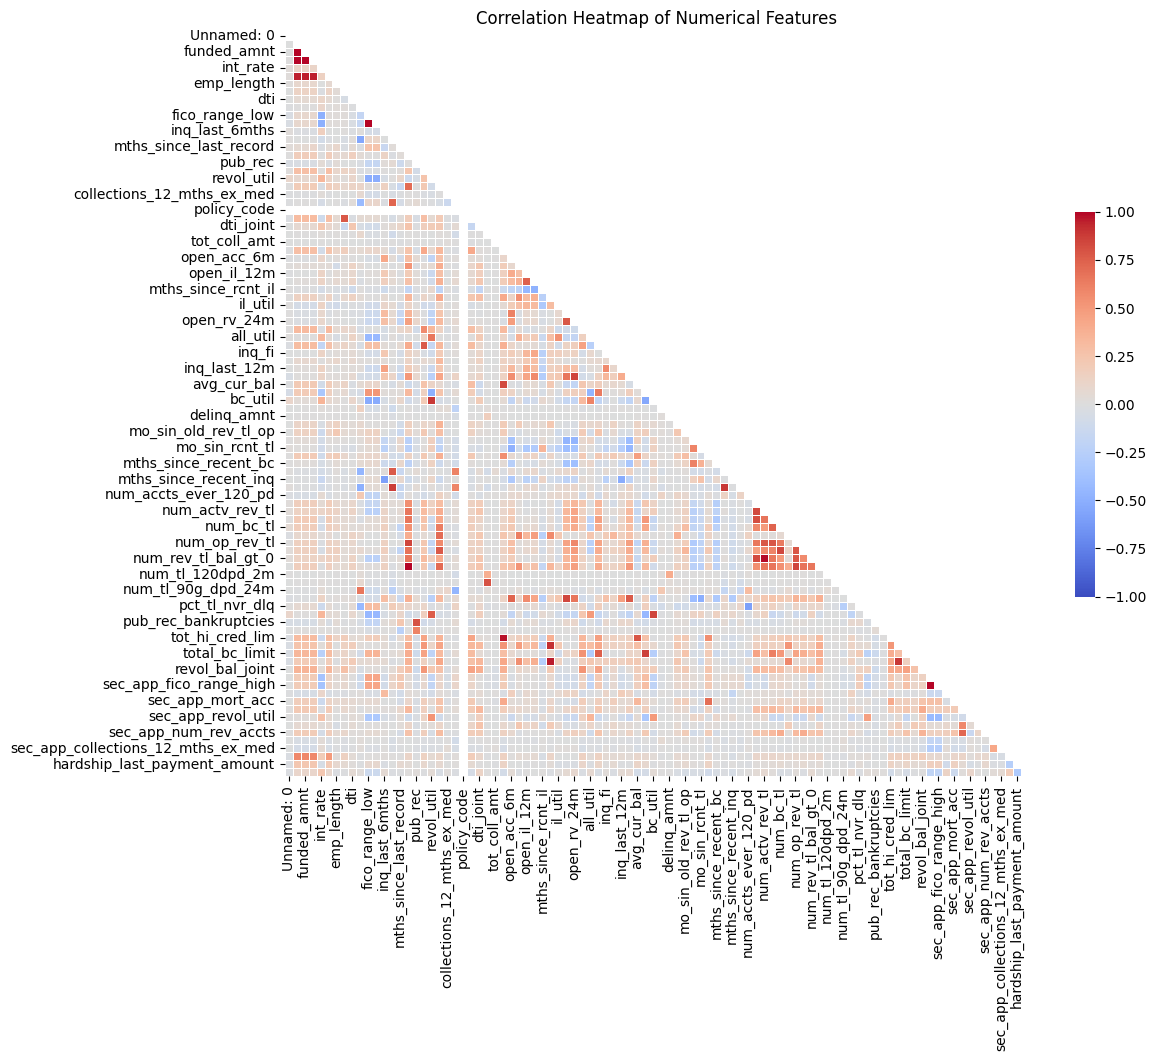

Variance Inflation Factor (VIF):
       feature       VIF
2  installment  8.484081
0    loan_amnt  5.806358
5   revol_util  2.103688
4          dti  1.821751
3   annual_inc  1.382225
1     int_rate  1.215811


In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numerical columns for correlation
num_df = df.select_dtypes(include=[np.number])

# 1. Correlation Matrix
plt.figure(figsize=(12, 10))
corr = num_df.corr()
# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 2. VIF Calculation (to check for multicollinearity)
# Drop NaNs and target variable for VIF calculation
vif_df = num_df.drop(columns=['default_flag']).dropna()

# Calculate VIF for a subset of important looking features to save computation time
features_to_check = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'revol_util']
features_to_check = [f for f in features_to_check if f in vif_df.columns]

X_vif = vif_df[features_to_check]
X_vif['intercept'] = 1 # Adding intercept is required for VIF

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("Variance Inflation Factor (VIF):")
print(vif_data[vif_data['feature'] != 'intercept'].sort_values('VIF', ascending=False))
# Note: VIF > 5 indicates high multicollinearity. E.g., 'loan_amnt' and 'installment' are usually highly collinear.

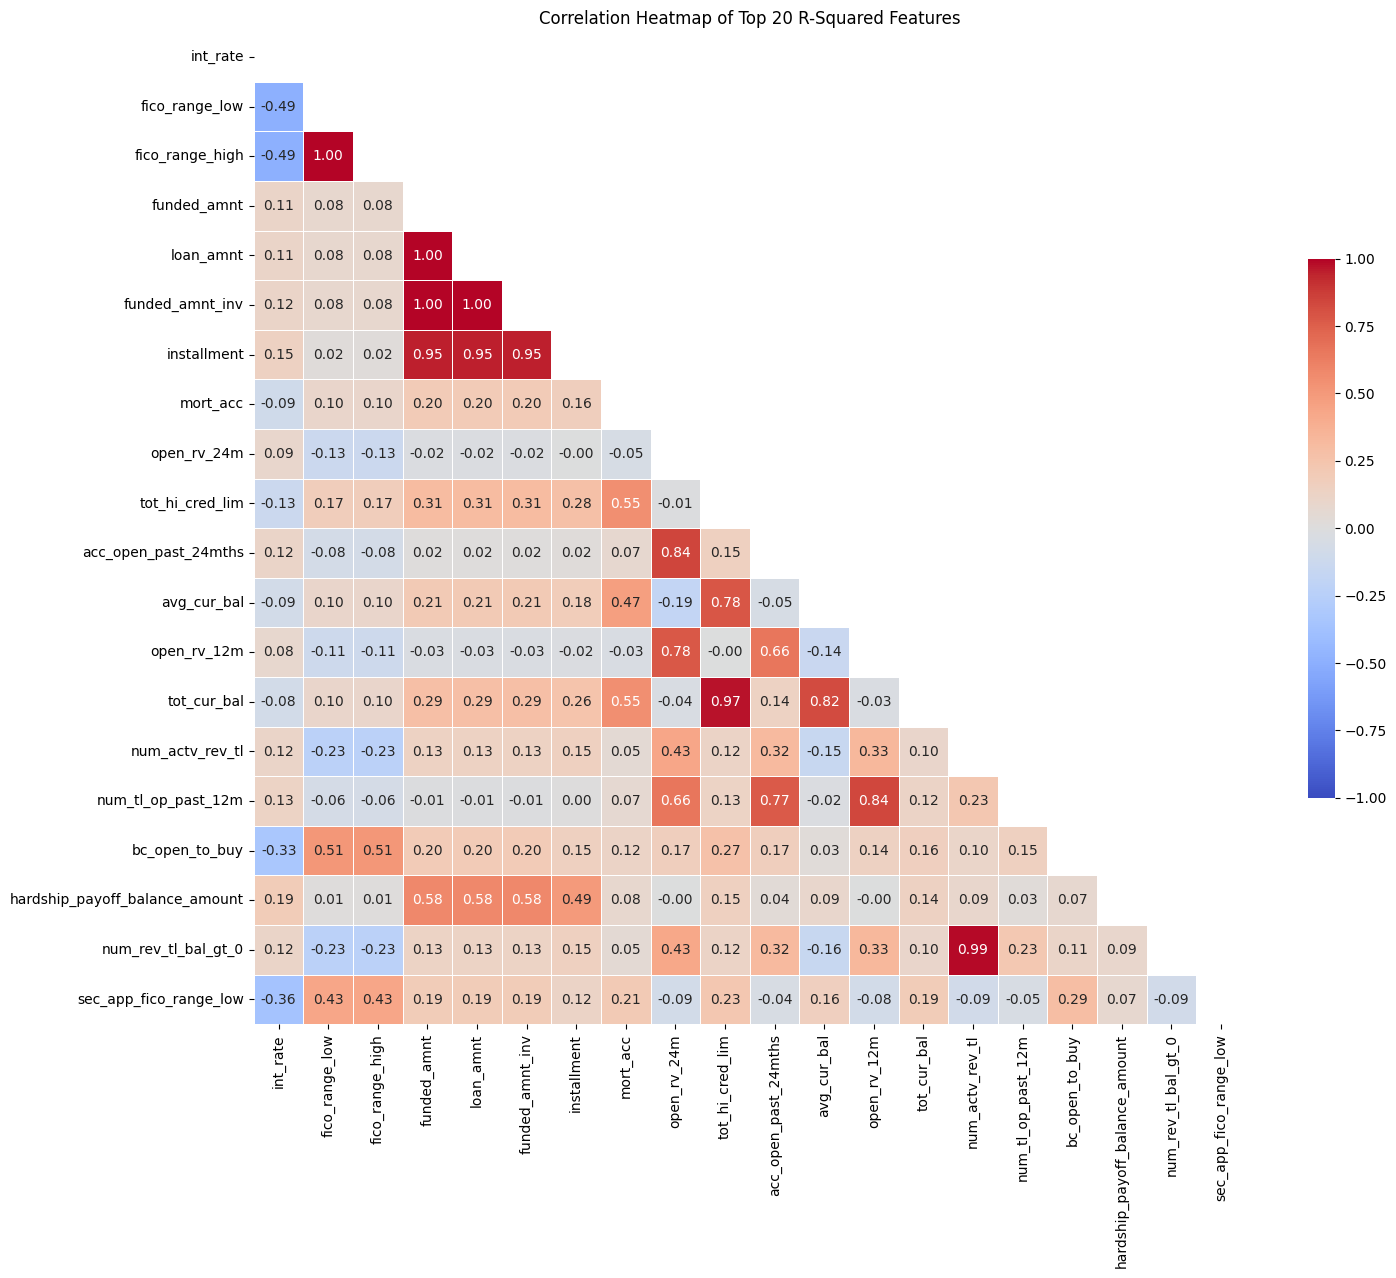

Variance Inflation Factor (VIF):
                           feature           VIF
3                      funded_amnt           inf
4                        loan_amnt           inf
1                   fico_range_low  6.923565e+05
2                  fico_range_high  6.923178e+05
5                  funded_amnt_inv  1.164001e+05
14                 num_actv_rev_tl  9.742022e+02
18             num_rev_tl_bal_gt_0  9.723998e+02
13                     tot_cur_bal  4.557161e+01
9                  tot_hi_cred_lim  4.146080e+01
10            acc_open_past_24mths  7.903516e+00
8                      open_rv_24m  7.703445e+00
6                      installment  7.479628e+00
15              num_tl_op_past_12m  7.130028e+00
12                     open_rv_12m  6.891590e+00
11                     avg_cur_bal  4.811516e+00
16                  bc_open_to_buy  1.894665e+00
17  hardship_payoff_balance_amount  1.608199e+00
7                         mort_acc  1.561181e+00
0                         int_rate  

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define the top 20 variables based on your Univariate R-Square scores
top_r2_features = [
    'int_rate', 'fico_range_low', 'fico_range_high', 'funded_amnt', 
    'loan_amnt', 'funded_amnt_inv', 'installment', 'mort_acc', 
    'open_rv_24m', 'tot_hi_cred_lim', 'acc_open_past_24mths', 
    'avg_cur_bal', 'open_rv_12m', 'tot_cur_bal', 'num_actv_rev_tl', 
    'num_tl_op_past_12m', 'bc_open_to_buy', 'hardship_payoff_balance_amount', 
    'num_rev_tl_bal_gt_0', 'sec_app_fico_range_low'
]

# Select only the available top features from the dataframe
features_to_use = [f for f in top_r2_features if f in df.columns]
num_df = df[features_to_use]

# 1. Correlation Matrix
plt.figure(figsize=(16, 14)) # Slightly larger to accommodate 20 variables
corr = num_df.corr()
# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=.5, annot=True, fmt=".2f", cbar_kws={"shrink": .5})
plt.title('Correlation Heatmap of Top 20 R-Squared Features')
plt.show()

# 2. VIF Calculation (to check for multicollinearity)
# Drop NaNs for VIF calculation (VIF cannot handle missing values)
vif_df = num_df.dropna()

X_vif = vif_df.copy()
X_vif['intercept'] = 1 # Adding intercept is required for VIF

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("Variance Inflation Factor (VIF):")
print(vif_data[vif_data['feature'] != 'intercept'].sort_values('VIF', ascending=False))
# Note: VIF > 5 indicates high multicollinearity. 
# Expect extremely high VIFs for 'loan_amnt', 'funded_amnt', and 'installment', 
# as well as 'fico_range_low' and 'fico_range_high'.

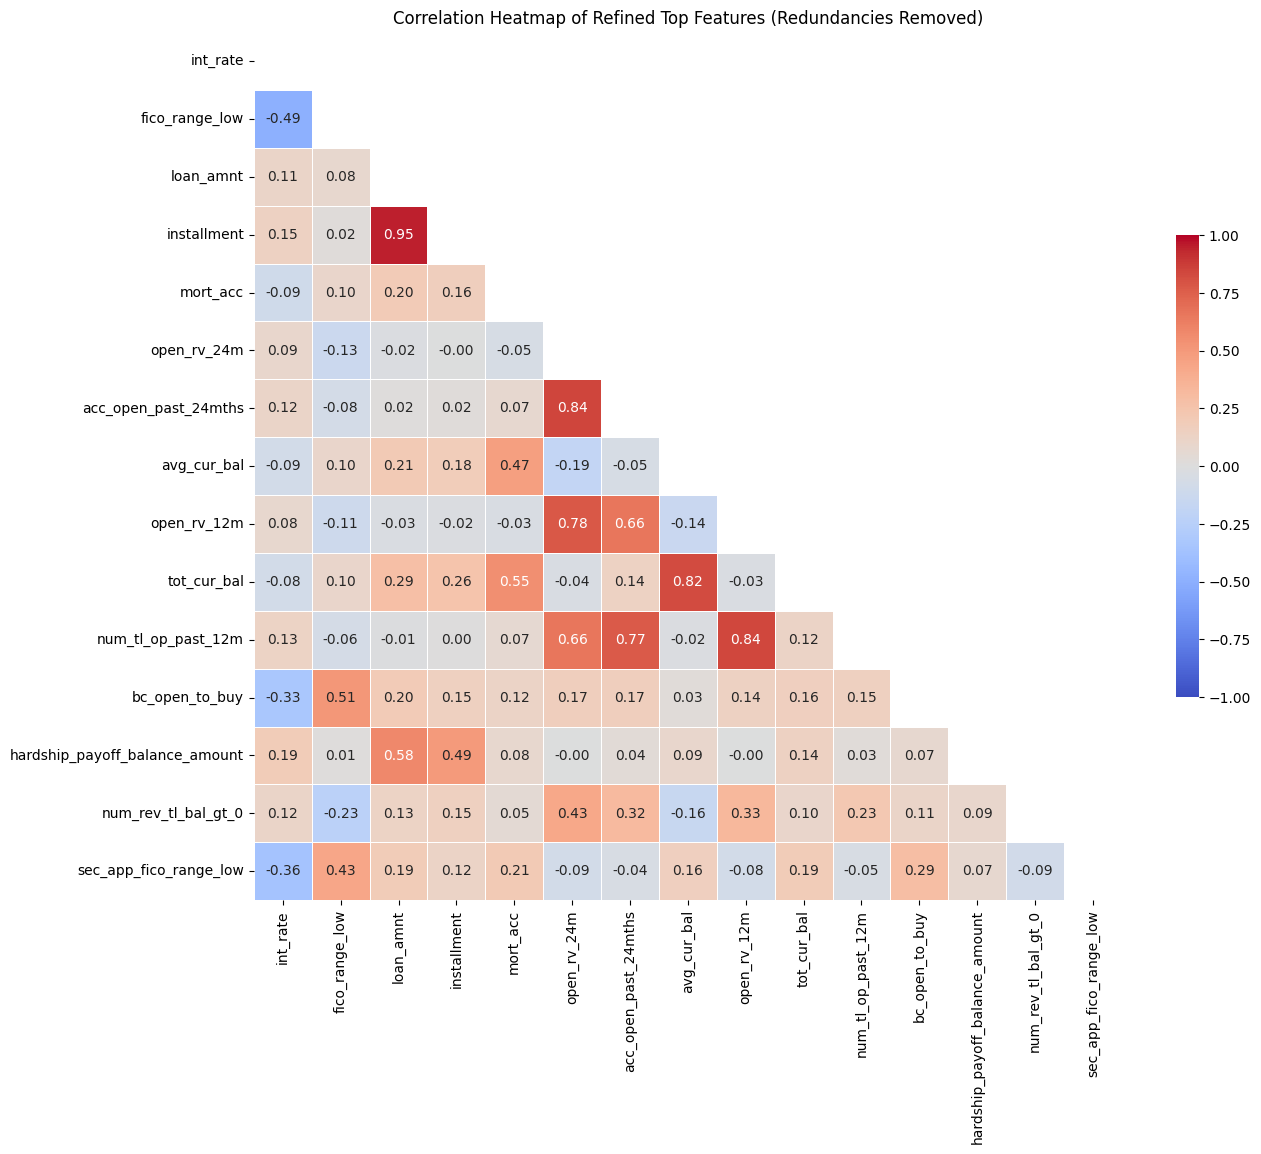

Variance Inflation Factor (VIF) - After Pruning Obvious Collinearity:
                       feature      VIF
                     loan_amnt 8.862822
          acc_open_past_24mths 7.893634
                   open_rv_24m 7.676985
                   installment 7.374364
            num_tl_op_past_12m 7.072250
                   open_rv_12m 6.844072
                   tot_cur_bal 5.576869
                   avg_cur_bal 4.782833
                fico_range_low 1.808852
           num_rev_tl_bal_gt_0 1.742717
hardship_payoff_balance_amount 1.604331
                bc_open_to_buy 1.573402
                      mort_acc 1.553411
                      int_rate 1.516995
        sec_app_fico_range_low 1.190250


In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Define the original top 20 variables based on Univariate R-Square scores
top_r2_features = [
    'int_rate', 'fico_range_low', 'fico_range_high', 'funded_amnt', 
    'loan_amnt', 'funded_amnt_inv', 'installment', 'mort_acc', 
    'open_rv_24m', 'tot_hi_cred_lim', 'acc_open_past_24mths', 
    'avg_cur_bal', 'open_rv_12m', 'tot_cur_bal', 'num_actv_rev_tl', 
    'num_tl_op_past_12m', 'bc_open_to_buy', 'hardship_payoff_balance_amount', 
    'num_rev_tl_bal_gt_0', 'sec_app_fico_range_low'
]

# 2. Define the obvious collinear features to drop based on the initial VIF analysis
# - funded_amnt & funded_amnt_inv: exact/near-exact duplicates of loan_amnt
# - fico_range_high: exact duplicate of fico_range_low (+4 points)
# - num_actv_rev_tl: near-exact duplicate of num_rev_tl_bal_gt_0
# - tot_hi_cred_lim: highly collinear with tot_cur_bal
features_to_drop = [
    'funded_amnt', 
    'funded_amnt_inv', 
    'fico_range_high', 
    'num_actv_rev_tl',
    'tot_hi_cred_lim'
]

# 3. Filter the features list
refined_features = [f for f in top_r2_features if f not in features_to_drop and f in df.columns]

# Create the subset dataframe
num_df = df[refined_features]

# --- 4. Correlation Matrix of the Refined Subset ---
plt.figure(figsize=(14, 12)) 
corr = num_df.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=.5, annot=True, fmt=".2f", cbar_kws={"shrink": .5})
plt.title('Correlation Heatmap of Refined Top Features (Redundancies Removed)')
plt.show()

# --- 5. VIF Calculation on the Refined Subset ---
# Drop NaNs for VIF calculation (VIF cannot handle missing values)
vif_df = num_df.dropna()

X_vif = vif_df.copy()
X_vif['intercept'] = 1 # Adding intercept is required for VIF

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("Variance Inflation Factor (VIF) - After Pruning Obvious Collinearity:")
# Exclude the intercept from the printed results and sort
print(vif_data[vif_data['feature'] != 'intercept'].sort_values('VIF', ascending=False).to_string(index=False))

In [52]:
print("Variance Inflation Factor (VIF):")
vif_no_intercept = vif_data[vif_data['feature'] != 'intercept']

print(vif_no_intercept.sort_values('VIF', ascending=False))

print("\nTop 50 lowest VIF:")
print(vif_no_intercept.sort_values('VIF', ascending=True).head(50).to_string(index=False))

Variance Inflation Factor (VIF):
                           feature       VIF
2                        loan_amnt  8.862822
6             acc_open_past_24mths  7.893634
5                      open_rv_24m  7.676985
3                      installment  7.374364
10              num_tl_op_past_12m  7.072250
8                      open_rv_12m  6.844072
9                      tot_cur_bal  5.576869
7                      avg_cur_bal  4.782833
1                   fico_range_low  1.808852
13             num_rev_tl_bal_gt_0  1.742717
12  hardship_payoff_balance_amount  1.604331
11                  bc_open_to_buy  1.573402
4                         mort_acc  1.553411
0                         int_rate  1.516995
14          sec_app_fico_range_low  1.190250

Top 50 lowest VIF:
                       feature      VIF
        sec_app_fico_range_low 1.190250
                      int_rate 1.516995
                      mort_acc 1.553411
                bc_open_to_buy 1.573402
hardship_payoff_balance_amo

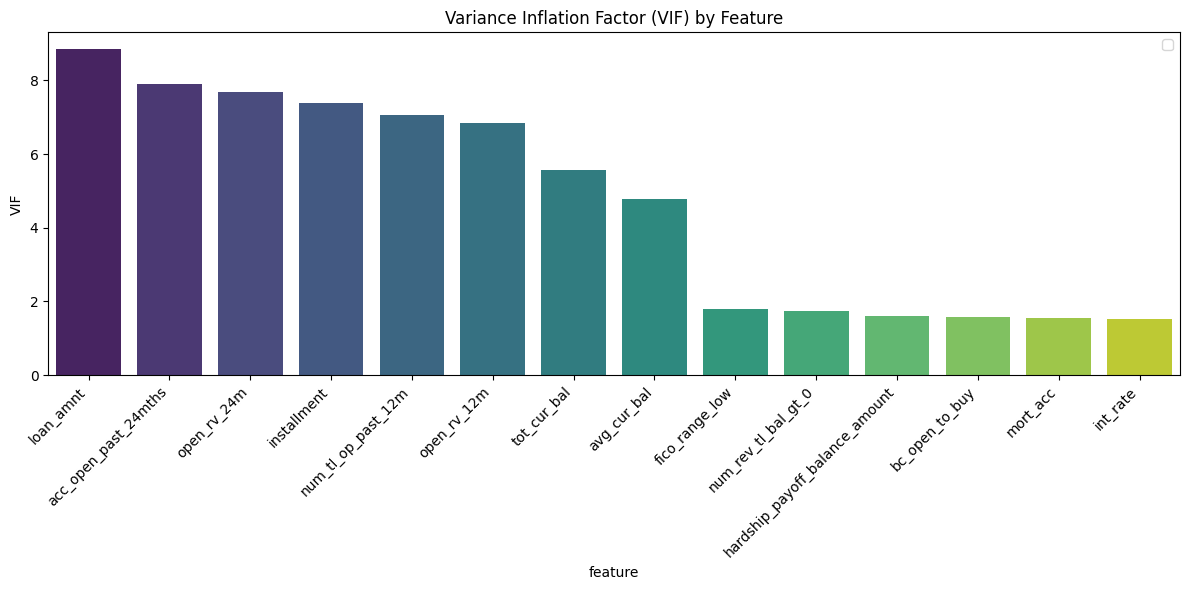

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# VIF data from the output
vif_data = {
    'feature': [
        'loan_amnt', 'acc_open_past_24mths', 'open_rv_24m', 'installment', 
        'num_tl_op_past_12m', 'open_rv_12m', 'tot_cur_bal', 'avg_cur_bal', 
        'fico_range_low', 'num_rev_tl_bal_gt_0', 'hardship_payoff_balance_amount', 
        'bc_open_to_buy', 'mort_acc', 'int_rate'
    ],
    'VIF': [
        8.862822, 7.893634, 7.676985, 7.374364, 7.072250, 6.844072, 
        5.576869, 4.782833, 1.808852, 1.742717, 1.604331, 1.573402, 
        1.553411, 1.516995
    ]
}

vif_df = pd.DataFrame(vif_data)

# Plot bar chart (since histogram for few points is better as bar)
plt.figure(figsize=(12, 6))
sns.barplot(x='feature', y='VIF', data=vif_df, palette='viridis')
plt.title('Variance Inflation Factor (VIF) by Feature')
plt.ylabel('VIF')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
k = 50 # Number of top correlations to display

# Calculate absolute correlation, unstack into pairs, and sort descending
corr_pairs = num_df.corr().abs().unstack().sort_values(ascending=False)

# Filter out self-correlations (where Variable A == Variable B)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Drop duplicate pairs (since corr(A, B) is the same as corr(B, A))
top_k_corr = corr_pairs[::2].head(k)

print(f"--- Top {k} Highest Correlations ---")
print(top_k_corr)

--- Top 50 Highest Correlations ---
loan_amnt                       installment                       0.950790
open_rv_24m                     acc_open_past_24mths              0.843987
open_rv_12m                     num_tl_op_past_12m                0.836440
tot_cur_bal                     avg_cur_bal                       0.824823
open_rv_24m                     open_rv_12m                       0.780824
num_tl_op_past_12m              acc_open_past_24mths              0.766960
                                open_rv_24m                       0.661437
open_rv_12m                     acc_open_past_24mths              0.657279
hardship_payoff_balance_amount  loan_amnt                         0.578971
tot_cur_bal                     mort_acc                          0.554479
fico_range_low                  bc_open_to_buy                    0.508129
installment                     hardship_payoff_balance_amount    0.492699
fico_range_low                  int_rate                        

Feature Importance

In [54]:
def calculate_woe_iv(df, feature, target):
    """Calculates Weight of Evidence (WoE) and Information Value (IV) for a feature."""
    lst = []
    
    # If numerical, bin it into 10 quantiles first
    if pd.api.types.is_numeric_dtype(df[feature]):
        df[feature + '_bin'] = pd.qcut(df[feature], q=10, duplicates='drop')
        group_col = feature + '_bin'
    else:
        group_col = feature
        
    for val in df[group_col].dropna().unique():
        val_df = df[df[group_col] == val]
        good = len(val_df[val_df[target] == 0])
        bad = len(val_df[val_df[target] == 1])
        lst.append({'Bin': val, 'Good': good, 'Bad': bad})
        
    dset = pd.DataFrame(lst)
    dset['Dist_Good'] = dset['Good'] / dset['Good'].sum()
    dset['Dist_Bad'] = dset['Bad'] / dset['Bad'].sum()
    # Avoid division by zero
    dset['Dist_Good'] = np.where(dset['Dist_Good'] == 0, 0.00001, dset['Dist_Good'])
    dset['Dist_Bad'] = np.where(dset['Dist_Bad'] == 0, 0.00001, dset['Dist_Bad'])
    
    dset['WoE'] = np.log(dset['Dist_Good'] / dset['Dist_Bad'])
    dset['IV'] = (dset['Dist_Good'] - dset['Dist_Bad']) * dset['WoE']
    iv = dset['IV'].sum()
    
    if pd.api.types.is_numeric_dtype(df[feature]):
        df.drop(columns=[feature + '_bin'], inplace=True)
        
    return iv

# Calculate IV for a list of features
features_to_evaluate = ['int_rate', 'dti', 'annual_inc', 'revol_util', 'emp_length_num', 'grade', 'home_ownership', 'purpose']
features_to_evaluate = [f for f in features_to_evaluate if f in df.columns]

iv_dict = {}
for col in features_to_evaluate:
    try:
        iv_dict[col] = calculate_woe_iv(df, col, 'default_flag')
    except Exception as e:
        pass # Skip columns that fail binning due to low variance

iv_df = pd.DataFrame.from_dict(iv_dict, orient='index', columns=['Information_Value']).sort_values('Information_Value', ascending=False)
print("Information Value (IV) by Feature:")
print(iv_df)
# Rule of thumb: IV < 0.02 (Useless), 0.02-0.1 (Weak), 0.1-0.3 (Medium), > 0.3 (Strong)

Information Value (IV) by Feature:
                Information_Value
grade                    0.334110
int_rate                 0.333688
dti                      0.041494
home_ownership           0.031894
annual_inc               0.019909
purpose                  0.016874
revol_util               0.012903


Feature Importance (Tree-based baseline)

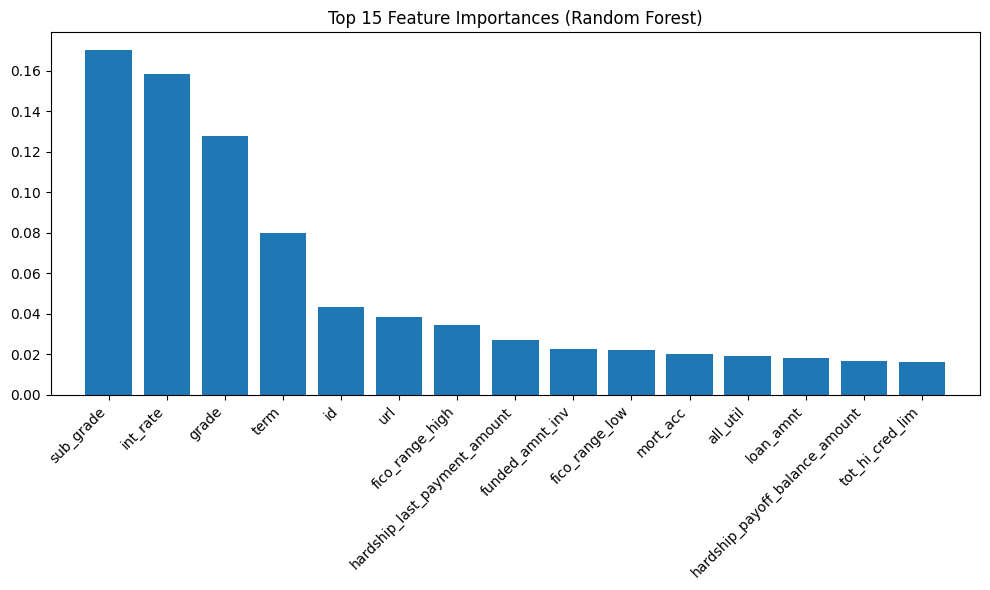

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Prepare data for Random Forest (Needs purely numeric/encoded data and no NaNs)
rf_df = df.copy()

# Encode Categorical Variables
categorical_cols = rf_df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    rf_df[col] = le.fit_transform(rf_df[col].astype(str))

# Drop datetime columns
datetime_cols = rf_df.select_dtypes(include=['datetime64']).columns
rf_df.drop(columns=datetime_cols, inplace=True)

# Separate X and y
X = rf_df.drop(columns=['default_flag'])
y = rf_df['default_flag']

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Train baseline Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5, n_jobs=-1)
rf.fit(X_imputed, y)

# Plot Feature Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 15 # Show top 15 features

plt.figure(figsize=(10, 6))
plt.title("Top 15 Feature Importances (Random Forest)")
plt.bar(range(top_n), importances[indices][:top_n], align="center")
plt.xticks(range(top_n), [X.columns[i] for i in indices][:top_n], rotation=45, ha='right')
plt.xlim([-1, top_n])
plt.tight_layout()
plt.show()

In [86]:
# 1. Install the library (uncomment the line below and run once if you don't have it installed)
# !pip install mrmr_selection

from mrmr import mrmr_classif
import pandas as pd

# --- Setup ---
# Ensure your features are in a pandas DataFrame 'X' and your target is a pandas Series 'y'
# Replace 'X' and 'y' below with your actual variable names if they differ.

# Specify how many optimal features you want to select. 
# The paper selected 12, but you can adjust this 'K' value based on your own feature count.
K_features = 100

#only numbers
X_numeric = X.select_dtypes(include=['number'])

print(f"Running mRMR to select the top {K_features} features...")

# 2. Perform mRMR selection
# Note: If your project is a regression task rather than classification, 
# import and use 'mrmr_regression' instead.
selected_features = mrmr_classif(X=X_numeric, y=y, K=K_features)

print("\n--- Optimal Features Selected ---")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

# 3. Create your new DataFrame with only the optimal features
X_optimal = X[selected_features]

# Verify the new shape
print(f"\nOriginal feature set shape: {X.shape}")
print(f"Optimal feature set shape: {X_optimal.shape}")

Running mRMR to select the top 100 features...


100%|██████████| 100/100 [01:05<00:00,  1.53it/s]



--- Optimal Features Selected ---
1. int_rate
2. total_cu_tl
3. emp_title
4. id
5. sub_grade
6. term
7. grade
8. avg_cur_bal
9. fico_range_low
10. installment
11. acc_open_past_24mths
12. fico_range_high
13. mort_acc
14. initial_list_status
15. funded_amnt
16. url
17. dti
18. loan_amnt
19. mths_since_recent_inq
20. home_ownership
21. funded_amnt_inv
22. open_rv_24m
23. verification_status
24. num_actv_rev_tl
25. tot_hi_cred_lim
26. num_tl_op_past_12m
27. application_type
28. hardship_last_payment_amount
29. collections_12_mths_ex_med
30. bc_open_to_buy
31. tot_cur_bal
32. mths_since_recent_bc
33. mo_sin_old_rev_tl_op
34. sec_app_inq_last_6mths
35. zip_code
36. all_util
37. num_rev_tl_bal_gt_0
38. inq_last_6mths
39. sec_app_fico_range_low
40. mo_sin_old_il_acct
41. sec_app_earliest_cr_line
42. sec_app_fico_range_high
43. total_bc_limit
44. mo_sin_rcnt_rev_tl_op
45. Unnamed: 0
46. open_rv_12m
47. dti_joint
48. inq_last_12m
49. verification_status_joint
50. num_actv_bc_tl
51. pub_rec
52.

In [82]:
# Save the optimal features selected by mRMR to a CSV file
optimal_features_df = pd.DataFrame(selected_features, columns=['Feature'])
#optimal_features_df.to_csv('optimal_features_mrmr.csv', index=False)

print("Optimal features saved to 'optimal_features_mrmr.csv'")

Optimal features saved to 'optimal_features_mrmr.csv'


100%|██████████| 11/11 [00:02<00:00,  4.96it/s]

Starting RFECV on mRMR selected features... this may take several minutes.


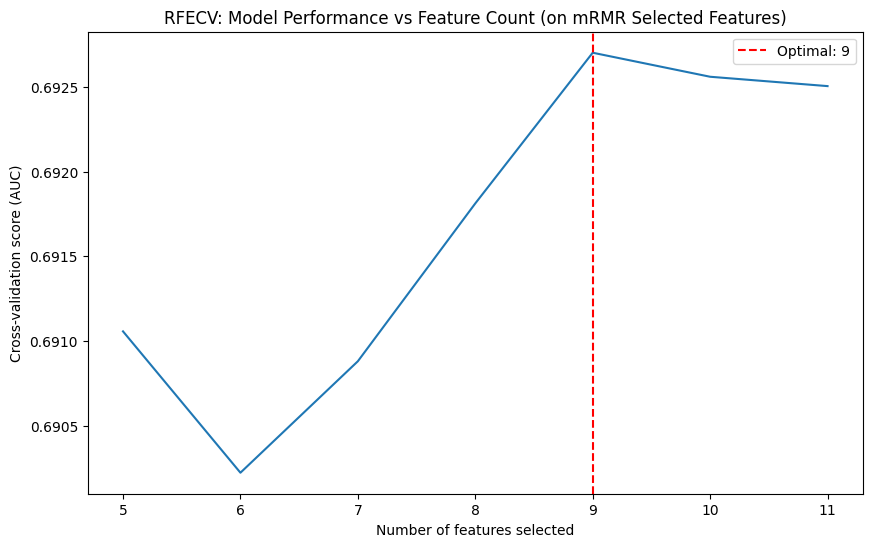

Optimal number of features: 9

The Optimal Features selected by RFECV from mRMR are:
- int_rate
- emp_length
- loan_amnt
- fico_range_low
- dti
- pub_rec
- annual_inc
- revol_util
- revol_bal


In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
from mrmr import mrmr_classif

# 1. Prepare a subset 
df_sample = df.sample(n=min(50000, len(df)), random_state=42)

# 2. Transform the data
X_transformed = preprocessor.fit_transform(df_sample.drop('default_flag', axis=1))
y_sample = df_sample['default_flag']
all_feature_names = np.array(num_cols + cat_cols)

# 3. First, select optimal features using mRMR on numerical features
X_numeric_sample = df_sample[num_cols].dropna()  # Use numerical features for mRMR
y_sample_mrmr = df_sample.loc[X_numeric_sample.index, 'default_flag']
selected_features = mrmr_classif(X=X_numeric_sample, y=y_sample_mrmr, K=50)

# 4. Get indices of selected features in all_feature_names
selected_indices = [np.where(all_feature_names == feat)[0][0] for feat in selected_features if feat in all_feature_names]

# 5. Subset X_transformed and all_feature_names to only mRMR selected features
X_transformed_subset = X_transformed[:, selected_indices]
all_feature_names_subset = all_feature_names[selected_indices]

# 6. Initialize the Estimator 
estimator = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    random_state=42, 
    n_jobs=-1,
    scale_pos_weight=(len(y_sample)-sum(y_sample))/sum(y_sample)
)

# 7. Run RFECV on the mRMR subset
selector = RFECV(
    estimator=estimator, 
    step=1, 
    cv=StratifiedKFold(3), 
    scoring='roc_auc',
    min_features_to_select=5,
    n_jobs=-1
)

print("Starting RFECV on mRMR selected features... this may take several minutes.")
selector = selector.fit(X_transformed_subset, y_sample)

# 8. Visualize the Results
plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (AUC)")

n_features_range = range(selector.min_features_to_select, len(all_feature_names_subset) + 1)
plt.plot(n_features_range, selector.cv_results_['mean_test_score'])

plt.title("RFECV: Model Performance vs Feature Count (on mRMR Selected Features)")
plt.axvline(x=selector.n_features_, color='r', linestyle='--', label=f'Optimal: {selector.n_features_}')
plt.legend()
plt.show()

# 9. Print the specific optimal features
print(f"Optimal number of features: {selector.n_features_}")
optimal_features = all_feature_names_subset[selector.support_]
print("\nThe Optimal Features selected by RFECV from mRMR are:")
for f in optimal_features:
    print(f"- {f}")

In [84]:
# After RFECV, apply K-Means Clustering Validation on the selected features

from sklearn.cluster import KMeans
from scipy.stats import f_oneway
import numpy as np

# Use the optimal features from RFECV
optimal_features = all_feature_names_subset[selector.support_]
indices_opt = [np.where(all_feature_names_subset == f)[0][0] for f in optimal_features]

# Subset the transformed data to optimal features
X_opt = X_transformed_subset[:, indices_opt]

# Perform K-Means clustering (assuming 3 clusters for risk levels: low, medium, high)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_opt)

# Validate each feature using ANOVA F-test
validated_features = []
for i, feat in enumerate(optimal_features):
    # Get the feature data
    feature_data = X_opt[:, i]
    
    # Group by clusters
    groups = [feature_data[clusters == c] for c in range(3)]
    
    # Perform ANOVA
    f_stat, p_val = f_oneway(*groups)
    
    # Retain if p-value <= 0.01
    if p_val <= 0.01:
        validated_features.append(feat)
    else:
        print(f"Eliminating feature '{feat}' due to p-value {p_val:.4f} > 0.01")

print(f"\nOriginal optimal features from RFECV: {len(optimal_features)}")
print(f"Validated features after K-Means clustering check: {len(validated_features)}")
print("\nFinal validated features:")
for f in validated_features:
    print(f"- {f}")

# Optionally, save the validated features
validated_df = pd.DataFrame(validated_features, columns=['Feature'])
validated_df.to_csv('validated_features_kmeans.csv', index=False)
print("\nValidated features saved to 'validated_features_kmeans.csv'")


Original optimal features from RFECV: 9
Validated features after K-Means clustering check: 9

Final validated features:
- int_rate
- emp_length
- loan_amnt
- fico_range_low
- dti
- pub_rec
- annual_inc
- revol_util
- revol_bal

Validated features saved to 'validated_features_kmeans.csv'


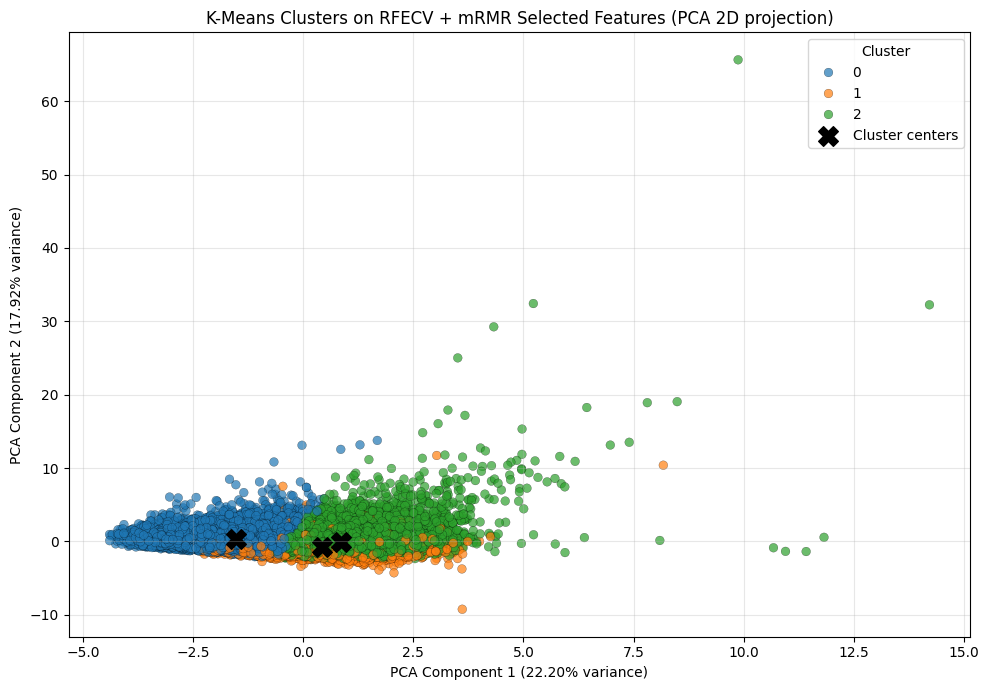

Cluster counts:
0    16755
1     6212
2    27033
Name: count, dtype: int64


In [85]:
from sklearn.decomposition import PCA

# Project the selected K-Means feature space to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_opt_2d = pca.fit_transform(X_opt)

cluster_centers_2d = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_opt_2d[:, 0],
    y=X_opt_2d[:, 1],
    hue=clusters,
    palette='tab10',
    s=40,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.2
)

plt.scatter(
    cluster_centers_2d[:, 0],
    cluster_centers_2d[:, 1],
    c='black',
    s=200,
    marker='X',
    label='Cluster centers'
)

plt.title('K-Means Clusters on RFECV + mRMR Selected Features (PCA 2D projection)')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Cluster counts:")
print(pd.Series(clusters).value_counts().sort_index())

In [57]:
print("all_feature_names length:", len(all_feature_names))
print("X_transformed shape:", X_transformed.shape)
print("y_sample length:", len(y_sample))
print("first 5 feature names:", all_feature_names[:5])

all_feature_names length: 15
X_transformed shape: (50000, 15)
y_sample length: 50000
first 5 feature names: ['loan_amnt' 'int_rate' 'annual_inc' 'dti' 'emp_length']


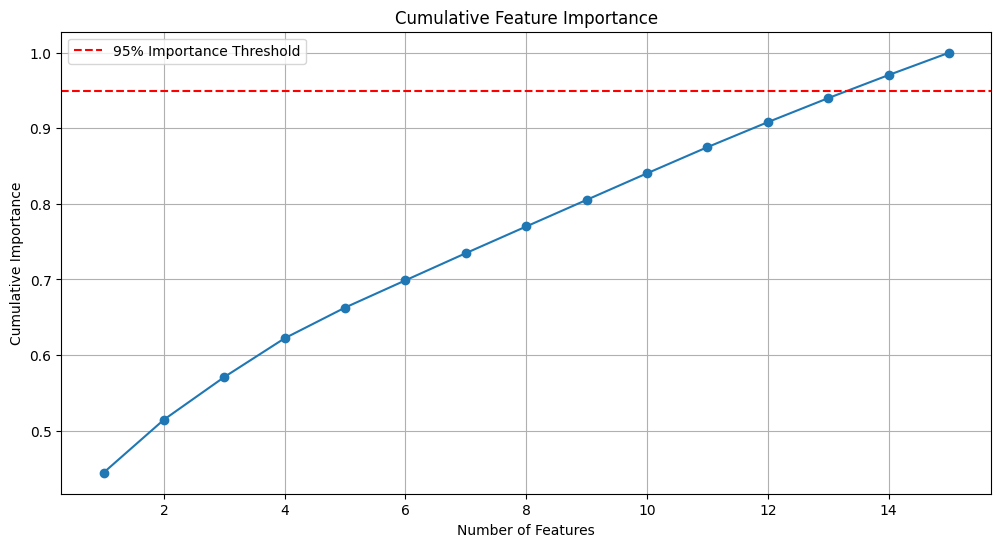

Number of features required to reach 95% importance: 14

Top features that make up 95% cumulative importance (in order):
1. home_ownership
2. grade
3. purpose
4. int_rate
5. loan_amnt
6. revol_bal
7. annual_inc
8. pub_rec
9. revol_util
10. dti
11. emp_length
12. default_flag
13. fico_range_low
14. open_acc


In [58]:
# 1. Train a full model once
full_model = xgb.XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1)
full_model.fit(X_transformed, y_sample)

# 2. Extract and Sort Importances
importances = pd.DataFrame({
    'feature': all_feature_names,
    'importance': full_model.feature_importances_
}).sort_values('importance', ascending=False)

# 3. Calculate Cumulative Importance
importances['cumulative_importance'] = importances['importance'].cumsum()

# 4. Visualize
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(importances) + 1), importances['cumulative_importance'], marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Importance Threshold')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.grid(True)
plt.legend()
plt.show()

# Find the exact number of features needed for 95% importance
num_95 = np.where(importances['cumulative_importance'] > 0.95)[0][0] + 1
print(f"Number of features required to reach 95% importance: {num_95}")

# Print the actual features contributing to 95% cumulative importance
top_features = importances.head(num_95)['feature'].tolist()
print("\nTop features that make up 95% cumulative importance (in order):")
for i, f in enumerate(top_features, 1):
    print(f"{i}. {f}")



Univariable R-square

In [78]:
# 1. Install the library (uncomment the line below and run once if you don't have it installed)
# !pip install mrmr_selection

from mrmr import mrmr_classif
import pandas as pd

# --- Setup ---
# Ensure your features are in a pandas DataFrame 'X' and your target is a pandas Series 'y'
# Replace 'X' and 'y' below with your actual variable names if they differ.

# Specify how many optimal features you want to select. 
# The paper selected 12, but you can adjust this 'K' value based on your own feature count.
K_features = 50

#only numbers
X_numeric = X.select_dtypes(include=['number'])

print(f"Running mRMR to select the top {K_features} features...")

# 2. Perform mRMR selection
# Note: If your project is a regression task rather than classification, 
# import and use 'mrmr_regression' instead.
selected_features = mrmr_classif(X=X_numeric, y=y, K=K_features)

print("\n--- Optimal Features Selected ---")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

# 3. Create your new DataFrame with only the optimal features
X_optimal = X[selected_features]

# Verify the new shape
print(f"\nOriginal feature set shape: {X.shape}")
print(f"Optimal feature set shape: {X_optimal.shape}")

Running mRMR to select the top 50 features...


100%|██████████| 50/50 [00:38<00:00,  1.31it/s]


--- Optimal Features Selected ---
1. int_rate
2. total_cu_tl
3. emp_title
4. id
5. sub_grade
6. term
7. grade
8. avg_cur_bal
9. fico_range_low
10. installment
11. acc_open_past_24mths
12. fico_range_high
13. mort_acc
14. initial_list_status
15. funded_amnt
16. url
17. dti
18. loan_amnt
19. mths_since_recent_inq
20. home_ownership
21. funded_amnt_inv
22. open_rv_24m
23. verification_status
24. num_actv_rev_tl
25. tot_hi_cred_lim
26. num_tl_op_past_12m
27. application_type
28. hardship_last_payment_amount
29. collections_12_mths_ex_med
30. bc_open_to_buy
31. tot_cur_bal
32. mths_since_recent_bc
33. mo_sin_old_rev_tl_op
34. sec_app_inq_last_6mths
35. zip_code
36. all_util
37. num_rev_tl_bal_gt_0
38. inq_last_6mths
39. sec_app_fico_range_low
40. mo_sin_old_il_acct
41. sec_app_earliest_cr_line
42. sec_app_fico_range_high
43. total_bc_limit
44. mo_sin_rcnt_rev_tl_op
45. Unnamed: 0
46. open_rv_12m
47. dti_joint
48. inq_last_12m
49. verification_status_joint
50. num_actv_bc_tl

Original featu

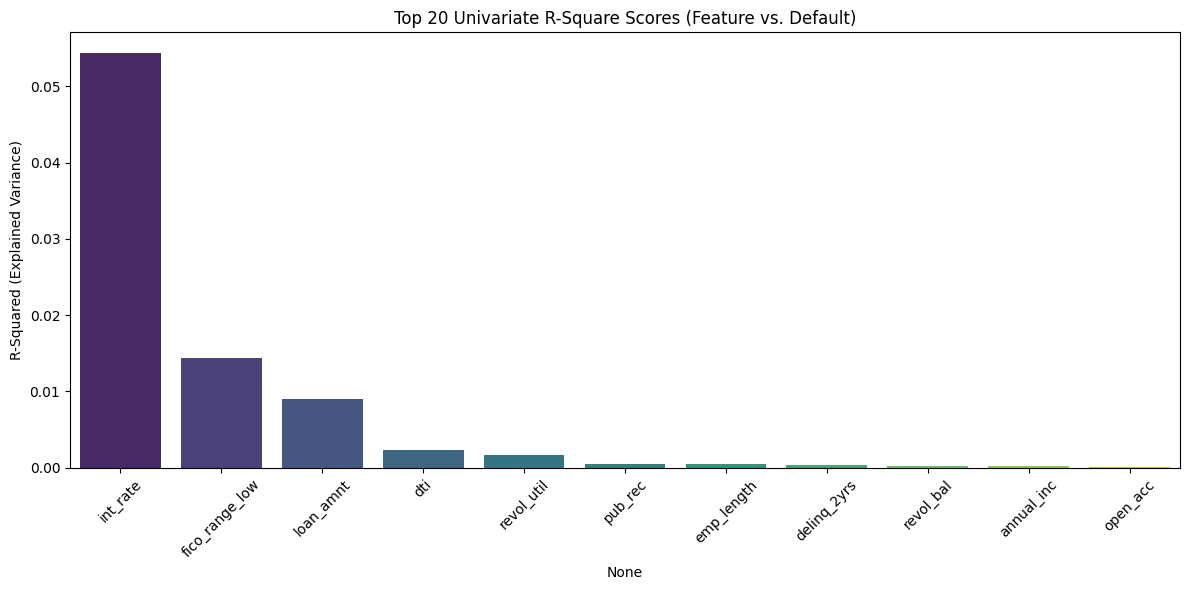

Top 20 Univariate R-Square Scores:
                R2_Score
int_rate        0.054373
fico_range_low  0.014449
loan_amnt       0.008952
dti             0.002355
revol_util      0.001702
pub_rec         0.000538
emp_length      0.000458
delinq_2yrs     0.000319
revol_bal       0.000198
annual_inc      0.000163
open_acc        0.000115


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Prepare numerical features (ensure they are scaled/imputed)
X_num = preprocessor.named_transformers_['num'].transform(df[num_cols])
y = df['default_flag']

r2_results = {}

# 2. Calculate R^2 for each numerical feature individually
for i, col in enumerate(num_cols):
    # Reshape for sklearn
    feature_val = X_num[:, i].reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(feature_val, y)
    predictions = model.predict(feature_val)
    
    r2 = r2_score(y, predictions)
    r2_results[col] = r2

# 3. Convert to DataFrame and Visualize
r2_df = pd.DataFrame.from_dict(r2_results, orient='index', columns=['R2_Score']).sort_values('R2_Score', ascending=False)
top20_r2_df = r2_df.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top20_r2_df.index, y=top20_r2_df['R2_Score'], palette='viridis')
plt.title('Top Univariate R-Square Scores (Feature vs. Default)')
plt.ylabel('R-Squared (Explained Variance)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Top Univariate R-Square Scores:")
print(top20_r2_df)

Cramer's V for categorical variable

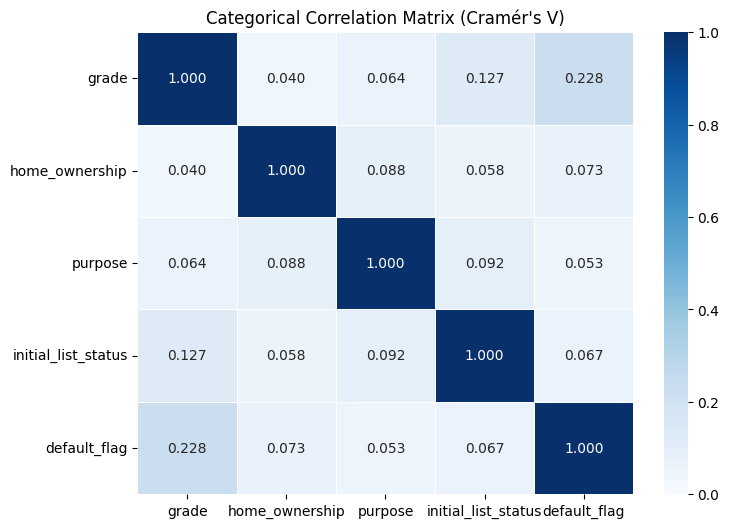


Categorical Predictive Power (Cramér's V vs default_flag):
grade                  0.228446
home_ownership         0.073201
initial_list_status    0.066799
purpose                0.053237
Name: default_flag, dtype: float64


In [69]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the Cramér's V function
def cramers_v(confusion_matrix):
    """ Calculate Cramér's V statistic for categorical-categorical association.
        Returns a value from 0 (no association) to 1 (perfect association).
    """
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Bias correction (prevents overestimating correlation in small samples)
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 2. Select Categorical Columns + Target
# Make sure to include 'default_flag' to see predictive power
cat_cols = ['grade', 'home_ownership', 'purpose', 'initial_list_status','default_flag']

# Keep only columns that actually exist in your dataframe
valid_cat_cols = [c for c in cat_cols if c in df.columns]

# 3. Create an empty correlation matrix
cramer_matrix = pd.DataFrame(index=valid_cat_cols, columns=valid_cat_cols)

# 4. Calculate Cramér's V for every combination
for col1 in valid_cat_cols:
    for col2 in valid_cat_cols:
        # Create a contingency table (cross-tabulation)
        confusion_matrix = pd.crosstab(df[col1], df[col2])
        # Calculate and store the score
        cramer_matrix.loc[col1, col2] = cramers_v(confusion_matrix)

# Convert all values to float for seaborn
cramer_matrix = cramer_matrix.astype(float)

# 5. Visualize the Categorical Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cramer_matrix, annot=True, cmap='Blues', vmin=0, vmax=1, fmt=".3f", linewidths=.5)
plt.title("Categorical Correlation Matrix (Cramér's V)")
plt.show()

# 6. Print the specific correlation to the Target Variable
if 'default_flag' in valid_cat_cols:
    print("\nCategorical Predictive Power (Cramér's V vs default_flag):")
    target_corr = cramer_matrix['default_flag'].drop('default_flag').sort_values(ascending=False)
    print(target_corr)

Mutual Information Score (Non linear correlation)

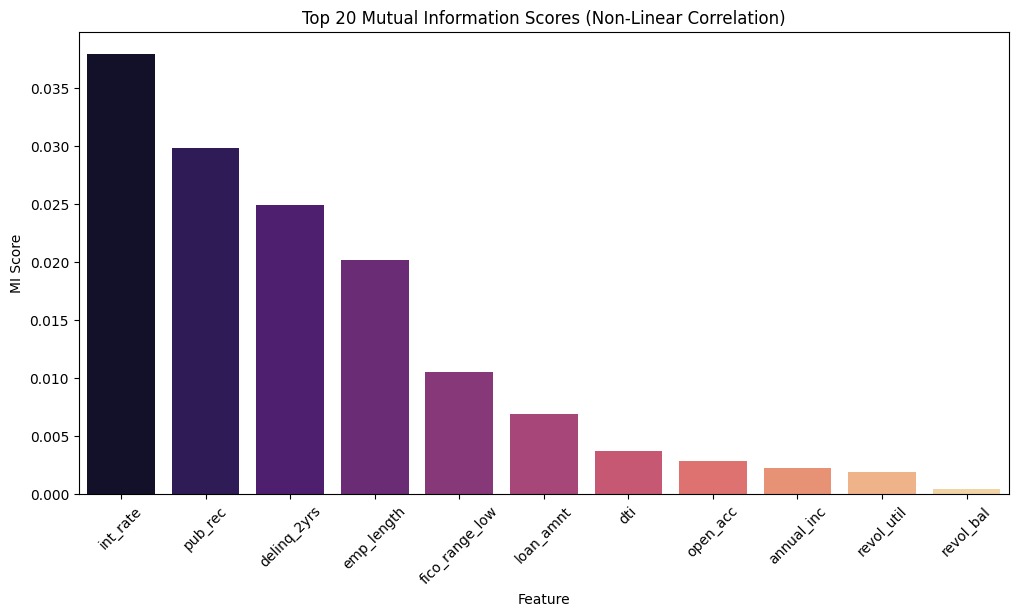

Top 20 Mutual Information Scores:
           Feature  MI_Score
1         int_rate  0.037929
10         pub_rec  0.029777
9      delinq_2yrs  0.024867
4       emp_length  0.020110
5   fico_range_low  0.010513
0        loan_amnt  0.006897
3              dti  0.003650
8         open_acc  0.002835
2       annual_inc  0.002216
6       revol_util  0.001848
7        revol_bal  0.000365


In [62]:
from sklearn.feature_selection import mutual_info_classif

# Calculate Mutual Information for the numerical features
mi_scores = mutual_info_classif(X_num, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature': num_cols,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

# Select top 20 features
top20_mi_df = mi_df.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x='Feature', y='MI_Score', data=top20_mi_df, palette='magma')
plt.title('Top 20 Mutual Information Scores (Non-Linear Correlation)')
plt.ylabel('MI Score')
plt.xticks(rotation=45)
plt.show()

print("Top 20 Mutual Information Scores:")
print(top20_mi_df)

Bivariate R-square score

In [75]:
from sklearn.linear_model import LinearRegression

# Define different combinations to test
combinations = {
    "Loan Profile": ['home_ownership', 'loan_amnt', 'emp_length', 'annual_inc', 'term', 'purpose', 'int_rate'],
    "Credit Utilization": ['revol_util', 'open_acc', 'mort_acc', 'inc_last_6mnths'],
    "Repayment History": ['delinq_2yrs', 'pub_rec'],
    "Debt Burden": ['dti', 'loan_amnt', 'revol_bal'],
    "All Core Static Features": ['loan_amnt', 'fico_range_low', 'dti', 'home_ownership']
}

feature_categories = {
    "Loan Profile": [
        "Unnamed: 0", 
        "id", 
        "loan_amnt", 
        "funded_amnt", 
        "funded_amnt_inv", 
        "term", 
        "int_rate", 
        "installment", 
        "grade", 
        "sub_grade", 
        "issue_d", 
        "pymnt_plan", 
        "url", 
        "purpose", 
        "title", 
        "initial_list_status", 
        "policy_code", 
        "application_type"
    ],
    
    "Credit Utilization": [
        "earliest_cr_line", 
        "inq_last_6mths", 
        "open_acc", 
        "revol_bal", 
        "revol_util", 
        "total_acc", 
        "open_acc_6m", 
        "open_act_il", 
        "open_il_12m", 
        "open_il_24m", 
        "mths_since_rcnt_il", 
        "total_bal_il", 
        "il_util", 
        "open_rv_12m", 
        "open_rv_24m", 
        "max_bal_bc", 
        "all_util", 
        "total_rev_hi_lim", 
        "inq_fi", 
        "total_cu_tl", 
        "inq_last_12m", 
        "acc_open_past_24mths", 
        "avg_cur_bal", 
        "bc_open_to_buy", 
        "bc_util", 
        "mo_sin_old_il_acct", 
        "mo_sin_old_rev_tl_op", 
        "mo_sin_rcnt_rev_tl_op", 
        "mo_sin_rcnt_tl", 
        "mort_acc", 
        "mths_since_recent_bc", 
        "mths_since_recent_inq", 
        "num_actv_bc_tl", 
        "num_actv_rev_tl", 
        "num_bc_sats", 
        "num_bc_tl", 
        "num_il_tl", 
        "num_op_rev_tl", 
        "num_rev_accts", 
        "num_rev_tl_bal_gt_0", 
        "num_sats", 
        "num_tl_op_past_12m", 
        "percent_bc_gt_75", 
        "tot_cur_bal", 
        "tot_hi_cred_lim", 
        "total_bal_ex_mort", 
        "total_bc_limit", 
        "total_il_high_credit_limit", 
        "revol_bal_joint", 
        "sec_app_earliest_cr_line", 
        "sec_app_inq_last_6mths", 
        "sec_app_mort_acc", 
        "sec_app_open_acc", 
        "sec_app_revol_util", 
        "sec_app_open_act_il", 
        "sec_app_num_rev_accts"
    ],
    
    "Repayment History": [
        "delinq_2yrs", 
        "fico_range_low", 
        "fico_range_high", 
        "mths_since_last_delinq", 
        "mths_since_last_record", 
        "pub_rec", 
        "collections_12_mths_ex_med", 
        "mths_since_last_major_derog", 
        "acc_now_delinq", 
        "tot_coll_amt", 
        "chargeoff_within_12_mths", 
        "delinq_amnt", 
        "mths_since_recent_bc_dlq", 
        "mths_since_recent_revol_delinq", 
        "num_accts_ever_120_pd", 
        "num_tl_120dpd_2m", 
        "num_tl_30dpd", 
        "num_tl_90g_dpd_24m", 
        "pct_tl_nvr_dlq", 
        "pub_rec_bankruptcies", 
        "tax_liens", 
        "sec_app_fico_range_low", 
        "sec_app_fico_range_high", 
        "sec_app_chargeoff_within_12_mths", 
        "sec_app_collections_12_mths_ex_med", 
        "default_flag"
    ],
    
    "Debt Burden": [
        "emp_title", 
        "emp_length", 
        "home_ownership", 
        "annual_inc", 
        "verification_status", 
        "zip_code", 
        "addr_state", 
        "dti", 
        "annual_inc_joint", 
        "dti_joint", 
        "verification_status_joint", 
        "hardship_payoff_balance_amount", 
        "hardship_last_payment_amount"
    ]
}

# We will use the preprocessor to ensure data is scaled correctly
# Note: For R2, we need the underlying numeric matrix
X_all_transformed = preprocessor.fit_transform(df.drop('default_flag', axis=1))
y = df['default_flag']

# Map the original column names to their indices in the transformed matrix
# (Since num_cols were the first 6 columns in our preprocessor)
feature_to_idx = {name: i for i, name in enumerate(num_cols)}

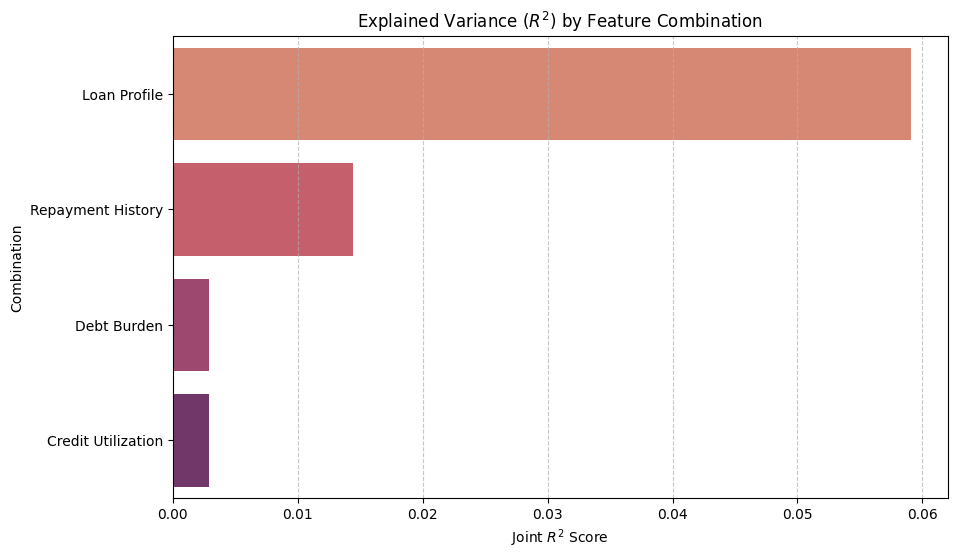

          Combination  R2_Score
0        Loan Profile  0.059050
2   Repayment History  0.014465
3         Debt Burden  0.002926
1  Credit Utilization  0.002917


In [77]:
combo_results = []

for label, cols in feature_categories.items():
    # Extract the indices for the current combination
    indices = [feature_to_idx[c] for c in cols if c in feature_to_idx]
    X_subset = X_all_transformed[:, indices]
    
    # Fit Linear Model
    model = LinearRegression()
    model.fit(X_subset, y)
    
    # Calculate R-Squared
    r2 = model.score(X_subset, y)
    combo_results.append({'Combination': label, 'R2_Score': r2})

# Convert to DataFrame
combo_df = pd.DataFrame(combo_results).sort_values('R2_Score', ascending=False)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='R2_Score', y='Combination', data=combo_df, palette='flare')
plt.title('Explained Variance ($R^2$) by Feature Combination')
plt.xlabel('Joint $R^2$ Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(combo_df)

In [65]:
# Exact top 27 transformed features
top27 = importances.head(num_95).copy()
print(top27[['feature', 'importance', 'cumulative_importance']])

# If you only want the names
top27_features = top27['feature'].tolist()
print(top27_features)

def map_back_to_raw(feat, num_cols, cat_cols):
    if feat in num_cols:
        return feat
    for c in cat_cols:
        if feat.startswith(c + "_"):
            return c
    return feat

top27['raw_variable'] = top27['feature'].apply(lambda x: map_back_to_raw(x, num_cols, cat_cols))
print(top27[['feature', 'raw_variable', 'importance', 'cumulative_importance']])
print("\nUnique raw variables used:")
print(top27['raw_variable'].unique().tolist())


           feature  importance  cumulative_importance
12  home_ownership    0.444350               0.444350
11           grade    0.070216               0.514566
13         purpose    0.056400               0.570966
1         int_rate    0.051282               0.622248
0        loan_amnt    0.040601               0.662849
7        revol_bal    0.036058               0.698907
2       annual_inc    0.035932               0.734839
10         pub_rec    0.035308               0.770147
6       revol_util    0.035201               0.805348
3              dti    0.035119               0.840467
4       emp_length    0.034618               0.875085
14    default_flag    0.033082               0.908167
5   fico_range_low    0.031775               0.939942
8         open_acc    0.030519               0.970461
['home_ownership', 'grade', 'purpose', 'int_rate', 'loan_amnt', 'revol_bal', 'annual_inc', 'pub_rec', 'revol_util', 'dti', 'emp_length', 'default_flag', 'fico_range_low', 'open_acc']
       